# Clean Energy Dominance Prediction using Logistic Regression

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler,MinMaxScaler

# Loading the Dataset

In [3]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Global renewable and fossil fuel energy.csv")
df

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
0,Aruba,ABW,Latin America & Caribbean,2000,0.2,NaN,0.000000,100.000000,100.000000,False
1,Aruba,ABW,Latin America & Caribbean,2001,0.2,NaN,0.000000,100.000000,100.000000,False
2,Aruba,ABW,Latin America & Caribbean,2002,0.2,NaN,0.000000,100.000000,100.000000,False
3,Aruba,ABW,Latin America & Caribbean,2003,0.2,NaN,0.000000,100.000000,100.000000,False
4,Aruba,ABW,Latin America & Caribbean,2004,0.2,NaN,0.000000,100.000000,100.000000,False
...,...,...,...,...,...,...,...,...,...,...
4852,Zimbabwe,ZWE,Sub-Saharan Africa,2018,79.7,0.0,63.033301,44.113566,107.146867,True
4853,Zimbabwe,ZWE,Sub-Saharan Africa,2019,81.0,0.0,68.845218,48.223229,117.068447,True
4854,Zimbabwe,ZWE,Sub-Saharan Africa,2020,84.1,0.0,60.785554,41.120935,101.906489,True
4855,Zimbabwe,ZWE,Sub-Saharan Africa,2021,82.4,0.0,72.628388,29.404206,102.032594,True


# Data Preprocessing

In [4]:
df.shape

(4857, 10)

In [5]:
df.head()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
0,Aruba,ABW,Latin America & Caribbean,2000,0.2,NaN,0.0,100.0,100.0,False
1,Aruba,ABW,Latin America & Caribbean,2001,0.2,NaN,0.0,100.0,100.0,False
2,Aruba,ABW,Latin America & Caribbean,2002,0.2,NaN,0.0,100.0,100.0,False
3,Aruba,ABW,Latin America & Caribbean,2003,0.2,NaN,0.0,100.0,100.0,False
4,Aruba,ABW,Latin America & Caribbean,2004,0.2,NaN,0.0,100.0,100.0,False


In [6]:
df.tail()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
4852,Zimbabwe,ZWE,Sub-Saharan Africa,2018,79.7,0.0,63.033301,44.113566,107.146867,True
4853,Zimbabwe,ZWE,Sub-Saharan Africa,2019,81.0,0.0,68.845218,48.223229,117.068447,True
4854,Zimbabwe,ZWE,Sub-Saharan Africa,2020,84.1,0.0,60.785554,41.120935,101.906489,True
4855,Zimbabwe,ZWE,Sub-Saharan Africa,2021,82.4,0.0,72.628388,29.404206,102.032594,True
4856,Zimbabwe,ZWE,Sub-Saharan Africa,2022,NaN,0.0,NaN,31.001608,NaN,False


In [7]:
df.sample()

,country,country_code,region,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share,clean_energy_dominant
3448,Philippines,PHL,East Asia & Pacific,2006,33.3,57.183452,36.082401,63.971611,100.054013,False


In [8]:
df.columns

Index(['country', 'country_code', 'region', 'year', 'renewable_energy_percent',
       'fossil_fuel_energy_percent', 'electricity_from_renewables_percent',
       'electricity_from_fossil_percent', 'total_electricity_share',
       'clean_energy_dominant'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857 entries, 0 to 4856
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              4857 non-null   object 
 1   country_code                         4857 non-null   object 
 2   region                               4857 non-null   object 
 3   year                                 4857 non-null   int64  
 4   renewable_energy_percent             4702 non-null   float64
 5   fossil_fuel_energy_percent           3380 non-null   float64
 6   electricity_from_renewables_percent  4396 non-null   float64
 7   electricity_from_fossil_percent      4648 non-null   float64
 8   total_electricity_share              4359 non-null   float64
 9   clean_energy_dominant                4857 non-null   bool   
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 346.4+ KB


In [10]:
df.describe()

,year,renewable_energy_percent,fossil_fuel_energy_percent,electricity_from_renewables_percent,electricity_from_fossil_percent,total_electricity_share
count,4857.000000,4702.000000,3380.000000,4396.000000,4648.000000,4359.000000
mean,2011.030471,29.850936,41.378435,29.723594,64.039153,96.028676
std,6.624015,29.534705,38.943092,31.622569,34.195710,12.709192
min,2000.000000,0.000000,-61.378855,0.000000,0.000000,19.417640
25%,2005.000000,4.400000,0.000000,2.180238,37.070009,99.279028
50%,2011.000000,19.100000,39.038562,16.831798,73.163972,100.000000
75%,2017.000000,50.175000,81.117627,53.471942,96.965113,100.001417
max,2022.000000,98.300000,99.994305,100.000000,100.000000,172.448980


# Checking Null Values

In [11]:
df.isnull().sum()

country                                   0
country_code                              0
region                                    0
year                                      0
renewable_energy_percent                155
fossil_fuel_energy_percent             1477
electricity_from_renewables_percent     461
electricity_from_fossil_percent         209
total_electricity_share                 498
clean_energy_dominant                     0
dtype: int64

In [12]:
df.isnull().sum() * 100/len(df)

country                                 0.000000
country_code                            0.000000
region                                  0.000000
year                                    0.000000
renewable_energy_percent                3.191270
fossil_fuel_energy_percent             30.409718
electricity_from_renewables_percent     9.491456
electricity_from_fossil_percent         4.303068
total_electricity_share                10.253243
clean_energy_dominant                   0.000000
dtype: float64

<Axes: >

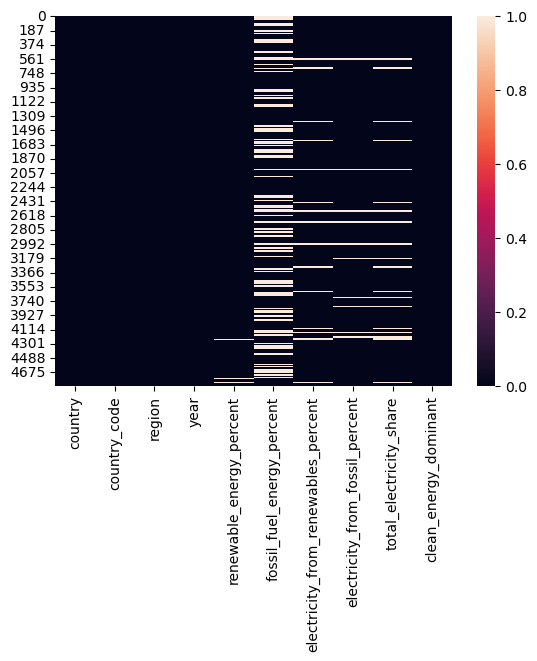

In [13]:
sns.heatmap(df.isnull())

# Data Wrangling (Filling Null/Missing Values)

In [44]:
num_cols = ['renewable_energy_percent','fossil_fuel_energy_percent','electricity_from_renewables_percent',
            'electricity_from_fossil_percent','total_electricity_share']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

<Axes: >

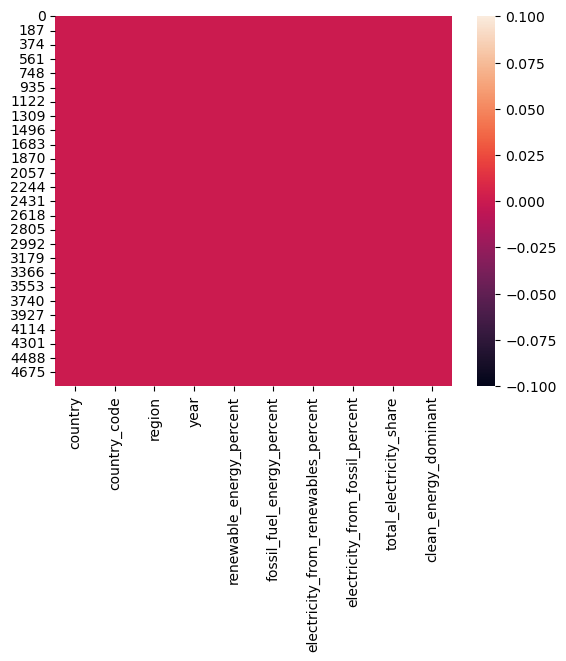

In [15]:
sns.heatmap(df.isnull())

In [43]:
df.isnull().sum()

country                                0
country_code                           0
region                                 0
year                                   0
renewable_energy_percent               0
fossil_fuel_energy_percent             0
electricity_from_renewables_percent    0
electricity_from_fossil_percent        0
total_electricity_share                0
clean_energy_dominant                  0
dtype: int64

# Data Visualization 

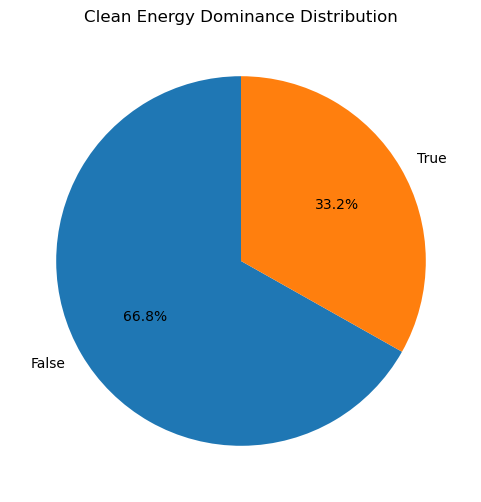

In [16]:
df['clean_energy_dominant'].value_counts().plot(
    kind='pie',autopct='%1.1f%%',figsize=(6,6),startangle=90)
plt.title("Clean Energy Dominance Distribution")
plt.ylabel("")
plt.show()


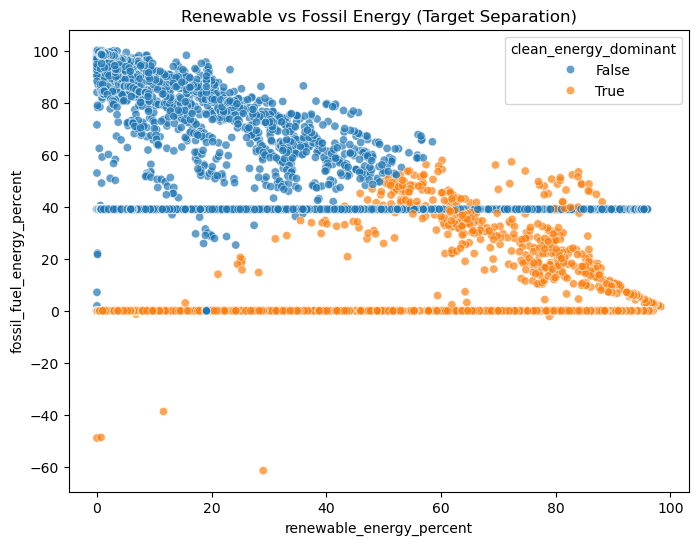

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='renewable_energy_percent',
    y='fossil_fuel_energy_percent',
    hue='clean_energy_dominant',
    data=df,
    alpha=0.7
)
plt.title("Renewable vs Fossil Energy (Target Separation)")
plt.show()

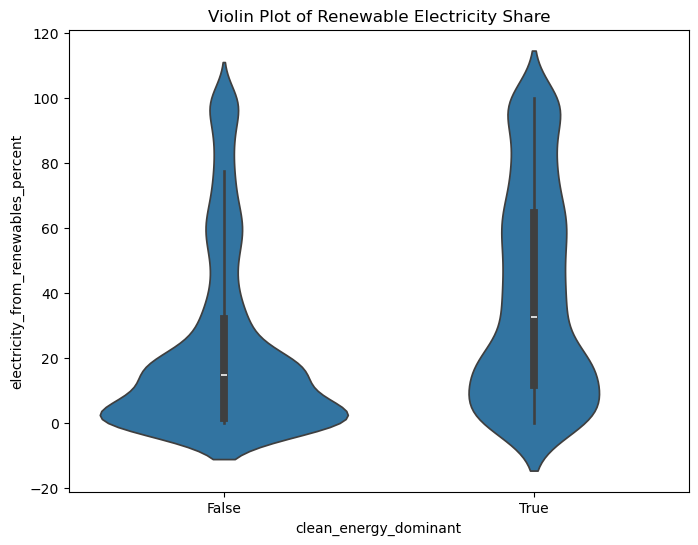

In [74]:
plt.figure(figsize=(8,6))
sns.violinplot(
    x='clean_energy_dominant',
    y='electricity_from_renewables_percent',
    data=df
)
plt.title("Violin Plot of Renewable Electricity Share")
plt.show()

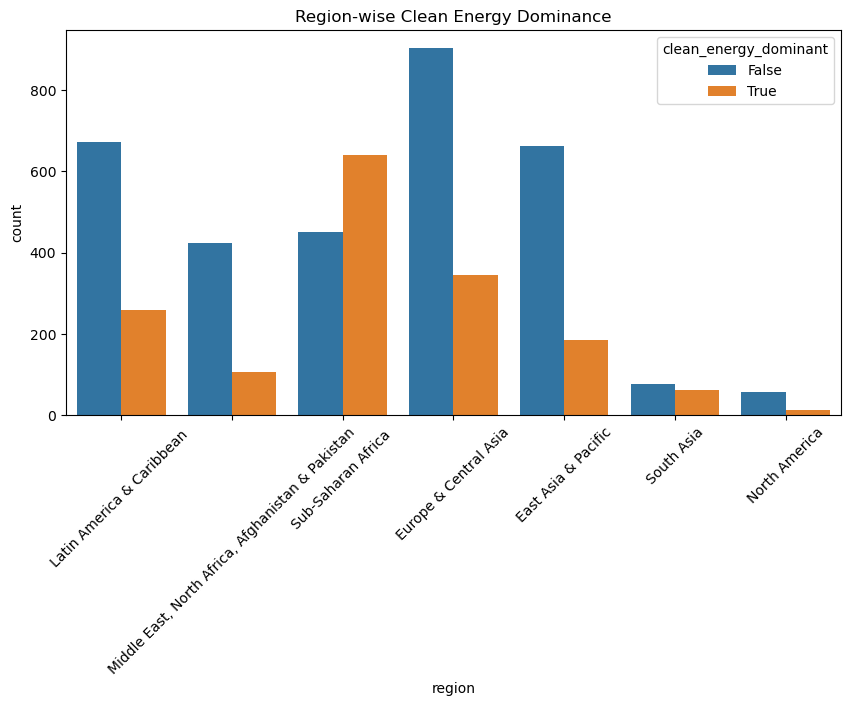

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='region',hue='clean_energy_dominant',data=df)
plt.xticks(rotation=45)
plt.title("Region-wise Clean Energy Dominance")
plt.show()


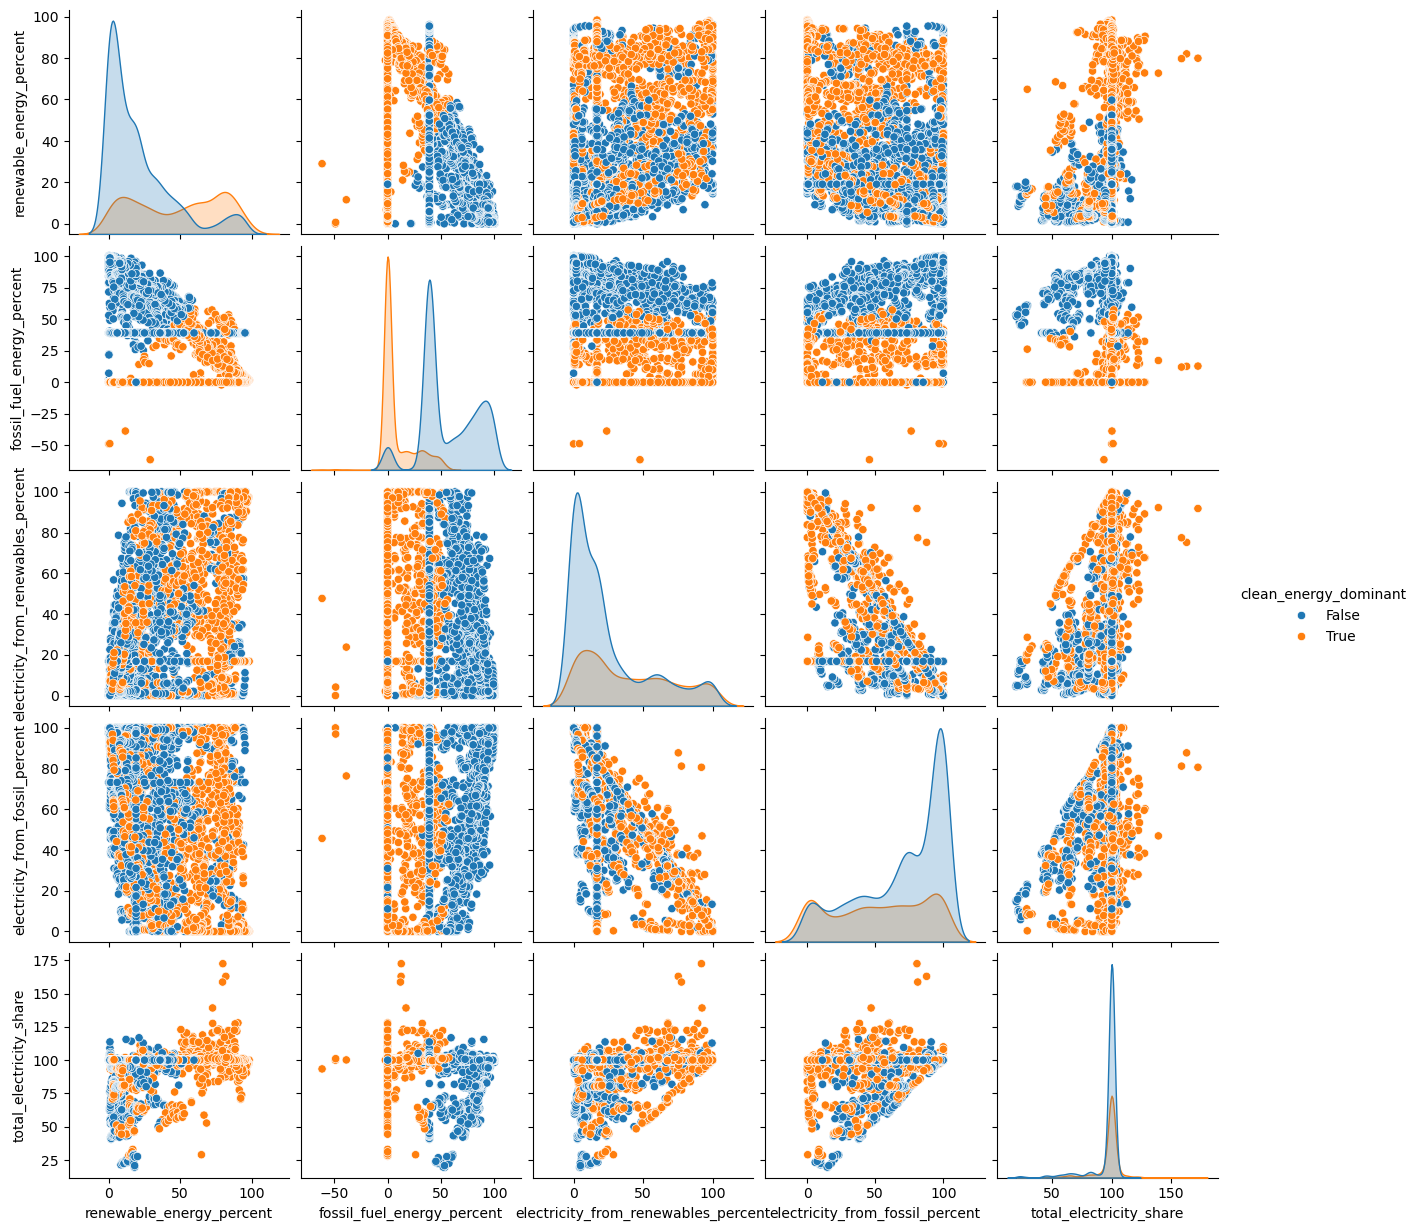

In [68]:
sns.pairplot(
    df[num_cols + ['clean_energy_dominant']],
    hue='clean_energy_dominant',
    diag_kind='kde'
)
plt.show()

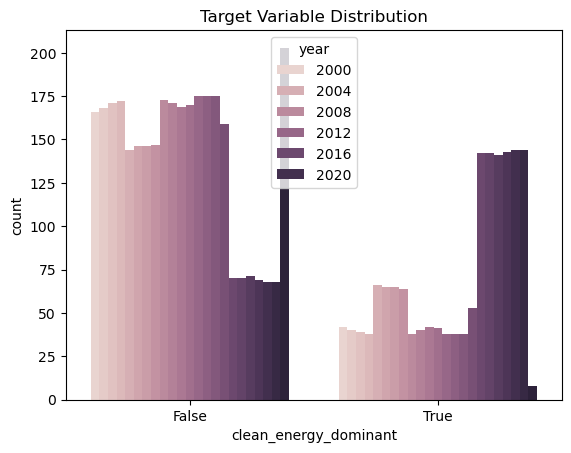

In [18]:
sns.countplot(x='clean_energy_dominant', data=df,hue='year')
plt.title("Target Variable Distribution")
plt.show()

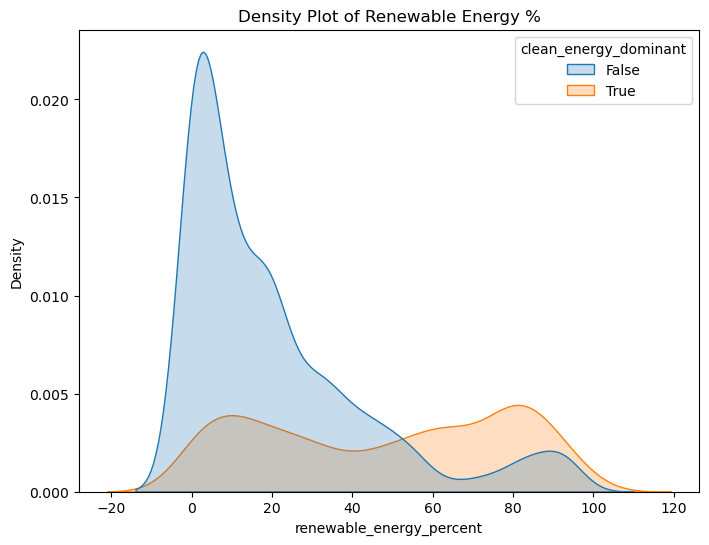

In [69]:
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df,
    x='renewable_energy_percent',
    hue='clean_energy_dominant',
    fill=True
)
plt.title("Density Plot of Renewable Energy %")
plt.show()

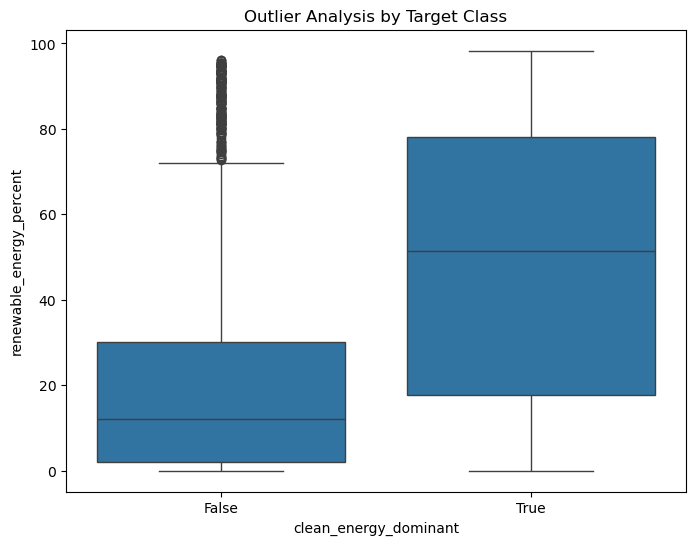

In [71]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='clean_energy_dominant',
    y='renewable_energy_percent',
    data=df
)
plt.title("Outlier Analysis by Target Class")
plt.show()

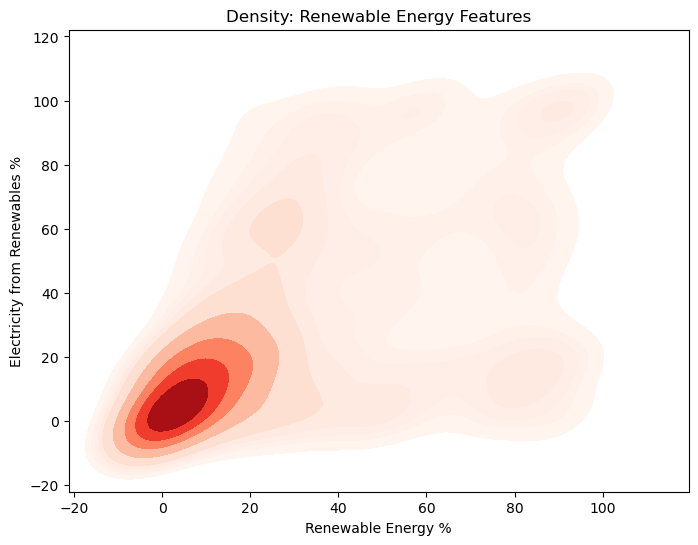

In [77]:
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=df['renewable_energy_percent'],
    y=df['electricity_from_renewables_percent'],
    cmap='Reds',
    fill=True,
    thresh=0.05,
    levels=10)

plt.xlabel("Renewable Energy %")
plt.ylabel("Electricity from Renewables %")
plt.title("Density: Renewable Energy Features")
plt.show()

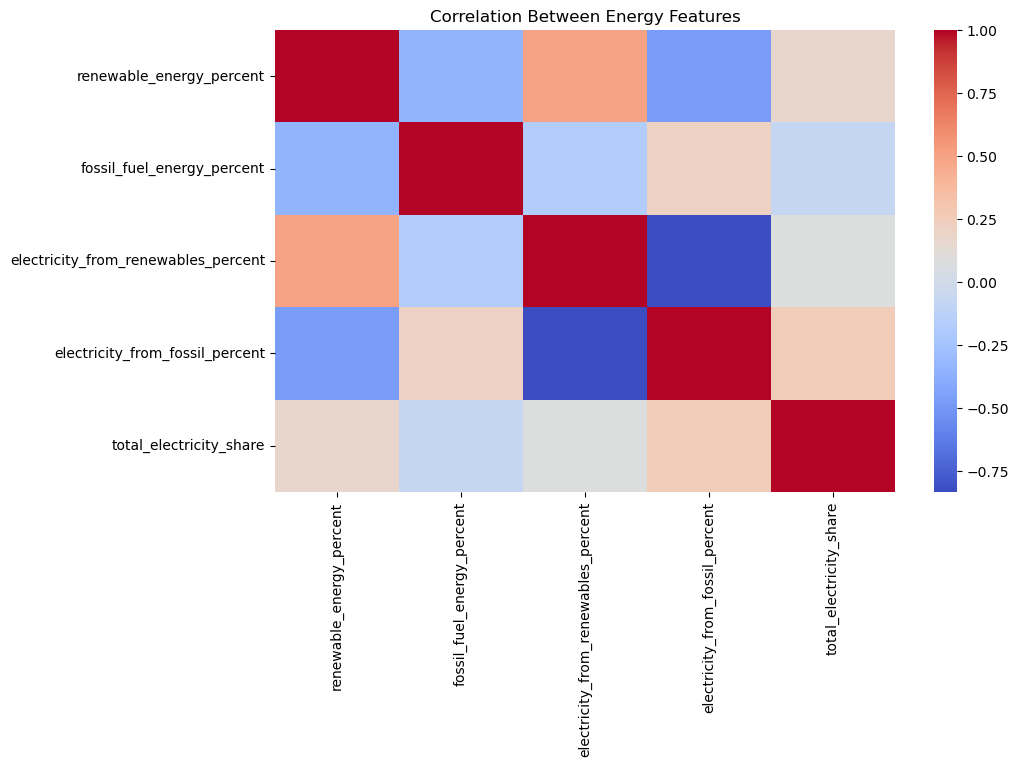

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(),cmap='coolwarm',annot=False)
plt.title("Correlation Between Energy Features")
plt.show()

# Label Encoding

In [20]:
df.dtypes

country                                 object
country_code                            object
region                                  object
year                                     int64
renewable_energy_percent               float64
fossil_fuel_energy_percent             float64
electricity_from_renewables_percent    float64
electricity_from_fossil_percent        float64
total_electricity_share                float64
clean_energy_dominant                     bool
dtype: object

In [21]:
cat_cols = df.select_dtypes(include='object')

In [22]:
label = LabelEncoder()
for c in cat_cols:
    df[c] = label.fit_transform(df[c])

# Feature Selection (x, y)

In [23]:
x = df[['country', 'region', 'year']]
y = df['clean_energy_dominant']

# Scaling

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Train-Test Split

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
import warnings
warnings.filterwarnings("ignore")

# Model Training

In [27]:
lor = LogisticRegression()
lor.fit(x_train, y_train)

LogisticRegression()

# Model Prediction 

In [28]:
y_pred = lor.predict(x_test)

# Model Evaluation 

## Accuracy Score

In [50]:
accuracy_score(y_test, y_pred)

0.7294238683127572

## Precision Score

In [51]:
precision_score(y_test, y_pred)

0.6041666666666666

## Recall Score

In [52]:
recall_score(y_test, y_pred)

0.38283828382838286

## Classification Report

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.76      0.89      0.82       669
        True       0.60      0.38      0.47       303

    accuracy                           0.73       972
   macro avg       0.68      0.63      0.64       972
weighted avg       0.71      0.73      0.71       972



## Confusion Matrix

In [53]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[593  76]
 [187 116]]


# GridSearchCV

In [54]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']}

In [55]:
grid = GridSearchCV(estimator=lor,param_grid=param_grid,cv=5,scoring='accuracy',
                    n_jobs=1,verbose=1)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [56]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.6988416988416988


In [59]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

# AUC-ROC

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

In [61]:
y_prob = best_model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.6708303117307246


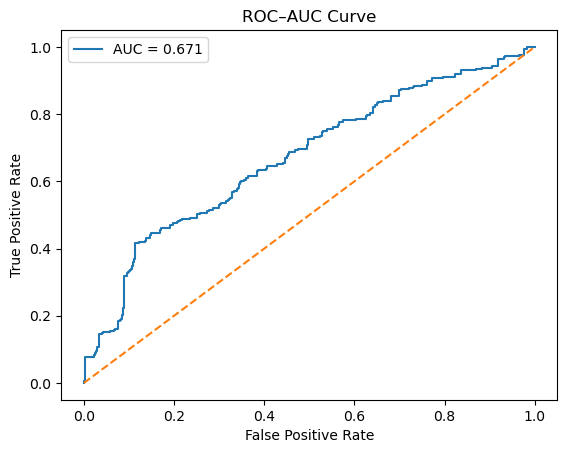

In [62]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve")
plt.legend()
plt.show()

# Threshold Tuning

In [41]:
thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresh))


Threshold: 0.3
Confusion Matrix:
[[446 223]
 [131 172]]
Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.67      0.72       669
        True       0.44      0.57      0.49       303

    accuracy                           0.64       972
   macro avg       0.60      0.62      0.60       972
weighted avg       0.67      0.64      0.65       972


Threshold: 0.4
Confusion Matrix:
[[571  98]
 [172 131]]
Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.85      0.81       669
        True       0.57      0.43      0.49       303

    accuracy                           0.72       972
   macro avg       0.67      0.64      0.65       972
weighted avg       0.71      0.72      0.71       972


Threshold: 0.5
Confusion Matrix:
[[593  76]
 [187 116]]
Classification Report:
              precision    recall  f1-score   support

       False       0.76      0.89      0.82       6